In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Documents\Customer churn\data\cleaned_customer_churn.csv")

In [7]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.shape

(7032, 21)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [12]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [14]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

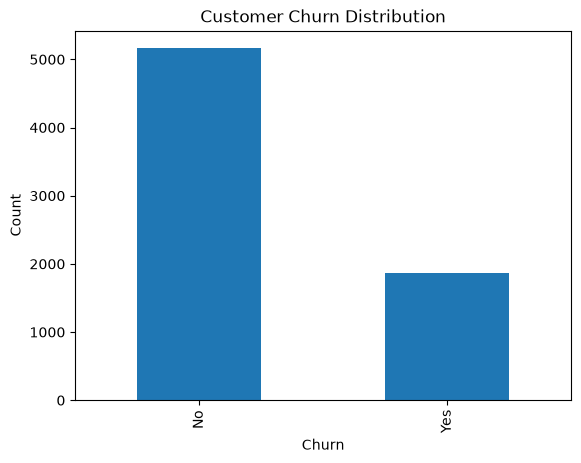

In [16]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

-Approximately 27% of customers have churned, while 73% remained with the company. 
-Although most customers are retained, the churn rate is still substantial, indicating an opportunity to improve customer retention strategies.

In [19]:
pd.crosstab(df["Contract"],df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [20]:
contract = pd.crosstab(df["Contract"],df["Churn"],normalize="index")
contract

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


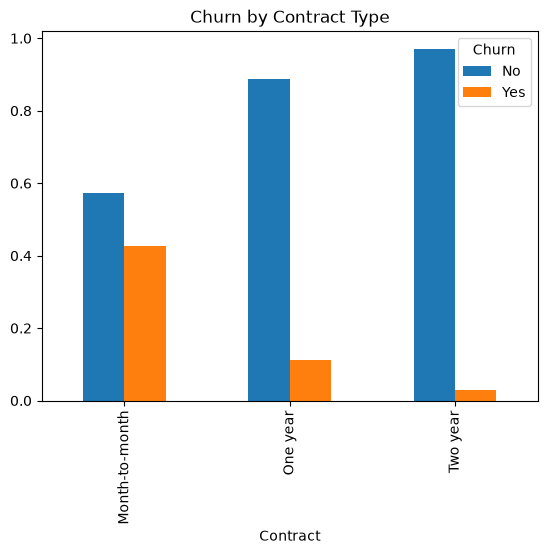

In [21]:
contract.plot(kind="bar")
plt.title("Churn by Contract Type")
plt.show()

-Customers on month-to-month contracts exhibit the highest churn rate (approximately 43%), whereas customers on one-year and two-year contracts are significantly more likely to remain with the company. 
-This suggests that longer-term contracts are associated with greater customer retention. 

In [23]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

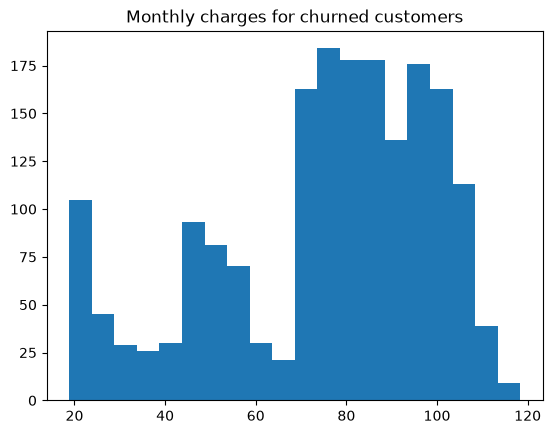

In [28]:
plt.hist(df[df["Churn"]=="Yes"]["MonthlyCharges"],bins=20)
plt.title("Monthly charges for churned customers")
plt.show()

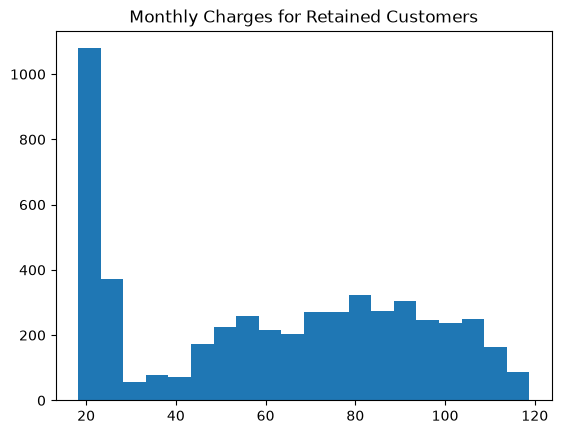

In [29]:
plt.hist(df[df["Churn"]=="No"]["MonthlyCharges"],bins=20)
plt.title("Monthly Charges for Retained Customers")
plt.show()

-Customers who churn tend to have higher monthly charges than those who remain.
-This indicates that higher monthly charges are associated with an increased likelihood of churn, although further analysis would be required to establish a causal relationship.

In [31]:
pd.crosstab(df["SeniorCitizen"],df["Churn"],normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.763497,0.236503
1,0.583187,0.416813


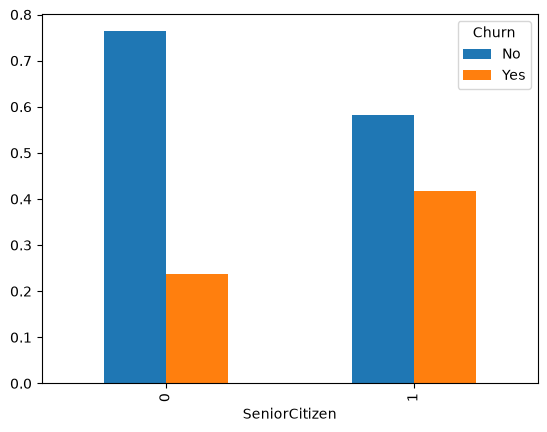

In [32]:
pd.crosstab(df["SeniorCitizen"],df["Churn"],normalize="index").plot(kind="bar")
plt.show()

-Approximately 42% of senior citizens churned compared with about 24% of non-senior customers, indicating that senior citizens have a higher observed churn rate.

In [33]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

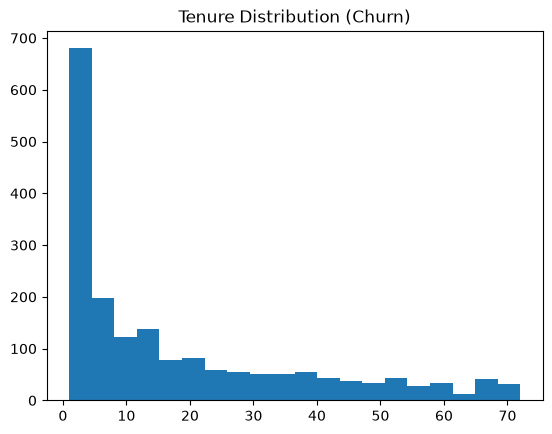

In [35]:
plt.hist(df[df["Churn"]=="Yes"]["tenure"],bins=20)
plt.title("Tenure Distribution (Churn)")
plt.show()

-Customers with shorter tenure exhibit a higher churn rate than long-term customers, suggesting that retaining customers during the early stages of their relationship with the company may be particularly important.

In [37]:
payment=pd.crosstab(df["Churn"],df["PaymentMethod"],normalize=True)
payment

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Churn,,,,
No,0.182594,0.183305,0.184016,0.1843
Yes,0.036689,0.032992,0.152304,0.0438


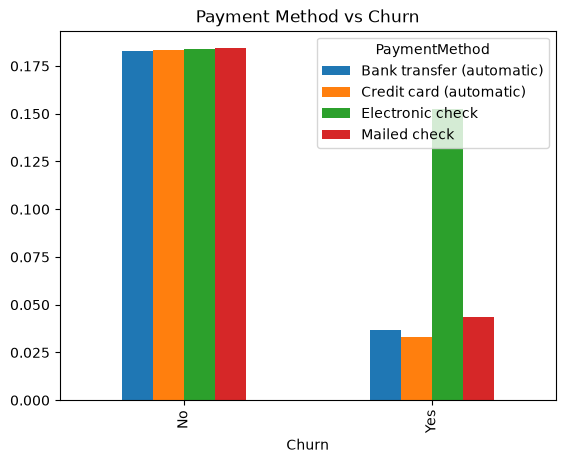

In [38]:
payment.plot(kind="bar")
plt.title("Payment Method vs Churn")
plt.show()

-Customers using electronic checks exhibit the highest churn rate.
-Customers paying through credit cards or bank transfers have comparatively lower churn rates, suggesting that payment method is associated with customer retention.

In [42]:
temp=df.copy()

In [43]:
temp["Churn"]=(temp["Churn"]=="Yes").astype(int)

In [44]:
numeric=temp.select_dtypes(include=np.number)

In [45]:
corr=numeric.corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484
Churn,0.150541,-0.354049,0.192858,-0.199484,1.000000


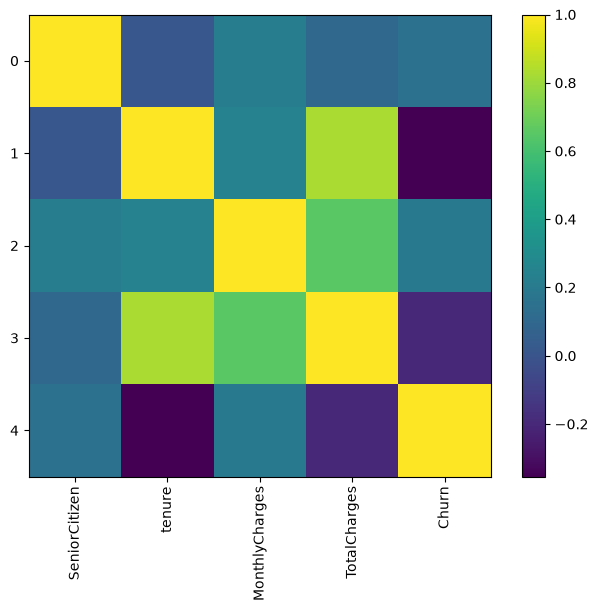

In [47]:
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.xticks(range(len(corr.columns)),corr.columns)
plt.show()